<a href="https://colab.research.google.com/github/touhid-sovon/machine_learning/blob/main/Supervised_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import IPython
import sklearn

# Sample DataSet

Classification - Forge dataset(synthetic -- made up )

In [2]:
!pip install mglearn
import mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.4 MB/s eta 0:00:00


X.shape: (26, 2)


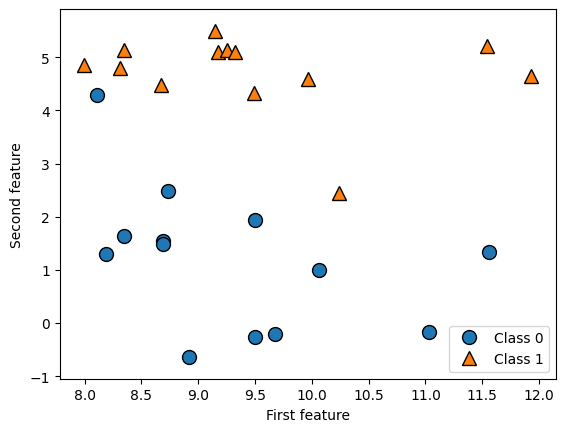

In [3]:
# generate dataset
X,y = mglearn.datasets.make_forge()
# plot dataset
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
print(f"X.shape: {X.shape}")

**Wave (synthetic) Dataset for Regression**

Text(0, 0.5, 'Target')

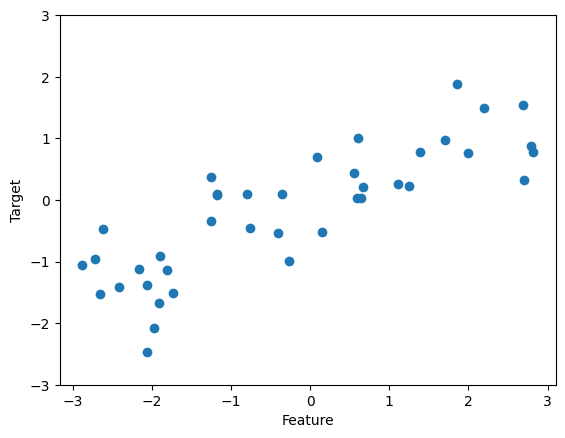

In [4]:
X, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X,y,'o')
plt.ylim(-3,3)
plt.xlabel("Feature")
plt.ylabel("Target")

**Breast Cancer DataSet**

In [5]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(f"cancer.keys(): \n{cancer.keys()}")

cancer.keys(): 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [6]:
print(f"The shape of the Cancer dataset: {cancer.data.shape}")

The shape of the Cancer dataset: (569, 30)


In [7]:
print(f"The shape of the Cancer dataset: {cancer.target_names.shape}")

The shape of the Cancer dataset: (2,)


In [8]:
print(f"The shape of the Cancer dataset: {cancer.target_names}")

The shape of the Cancer dataset: ['malignant' 'benign']


In [9]:
for name, count in zip(cancer.target_names, np.bincount(cancer.target)):
  print(f'{name} : {count}',end = " ")

malignant : 212 benign : 357 

In [10]:
print(f"The Fearture Names: \n{cancer.feature_names}")

The Fearture Names: 
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


**Boston Data Set**

In [11]:
# from sklearn.datasets import load_boston
# boston = load_boston()
# print(f"The shape of the Boston dataset: {boston.data.shape}")

**Extented Boston**

In [12]:
X,y = mglearn.datasets.load_extended_boston()
print(f"X.shape: {X.shape}")

X.shape: (506, 104)


In [13]:
for i in range(5):
  print(f"X[{i}]: {X[i][:3]}")

X[0]: [0.         0.18       0.06781525]
X[1]: [2.35922539e-04 0.00000000e+00 2.42302053e-01]
X[2]: [2.35697744e-04 0.00000000e+00 2.42302053e-01]
X[3]: [0.0002928  0.         0.06304985]
X[4]: [0.00070507 0.         0.06304985]


# KNN Agorithm

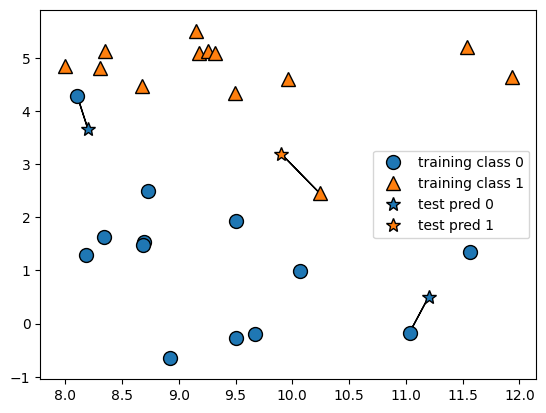

In [14]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

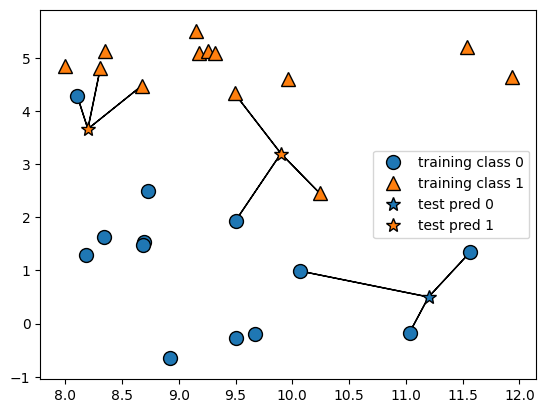

In [15]:
# for 3 neighbour
mglearn.plots.plot_knn_classification(n_neighbors=3)

**Using KNN to Forge Data**

In [16]:
from sklearn.neighbors import KNeighborsClassifier
cls = KNeighborsClassifier(n_neighbors=3)

In [17]:
print(type(cls))

<class 'sklearn.neighbors._classification.KNeighborsClassifier'>


In [18]:
print(dir(cls))

['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_build_request_for_signature', '_check_algorithm_metric', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_fit', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_kneighbors_reduce_func', '_more_tags', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_data', '_validate_params', 'algorithm', 'fit', 'get_metadata_routing', 'get_params', 'k

In [19]:
from sklearn.model_selection import train_test_split
X,y = mglearn.datasets.make_forge()
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

In [20]:
print(X_train.shape)

(19, 2)


In [21]:
cls.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [22]:
print(f'Test Set Prediction: {cls.predict(X_test)}')

Test Set Prediction: [1 0 1 0 1 0 0]


In [23]:
print(f'Test Set Accuracy: {cls.score(X_test,y_test):.2f}')

Test Set Accuracy: 0.86


**Analyzing KNeighbour Classifier**

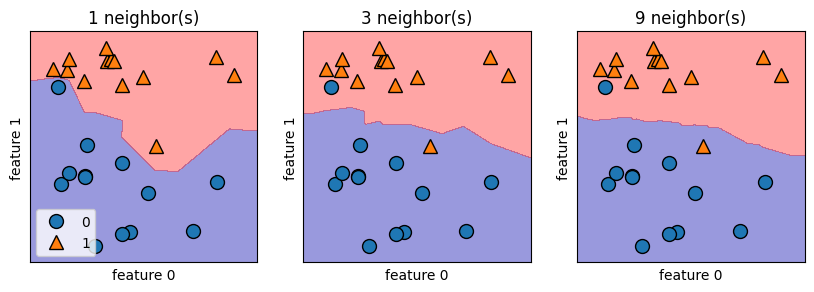

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for n_neighbors, ax in zip([1, 3, 9], axes):
    # the fit method returns the object self, so we can instantiate
    # and fit in one line
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title(f"{n_neighbors} neighbor(s)")
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
axes[0].legend(loc=3)

**Breast Cancer Classification**

In [25]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=66)

In [26]:
test_accuracy = []
training_accuracy = []

neighbors_settings = range(1,11)

for n_neighbours in neighbors_settings:
  cls = KNeighborsClassifier(n_neighbors = n_neighbours)
  cls.fit(X_train,y_train)
  training_accuracy.append(cls.score(X_train,y_train))
  test_accuracy.append(cls.score(X_test,y_test))



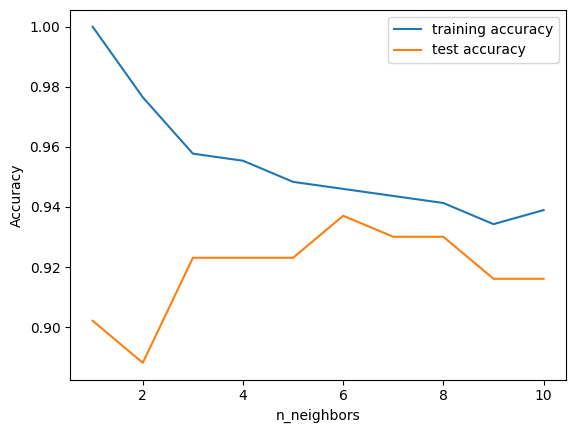

In [27]:
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

**KNN Regression**

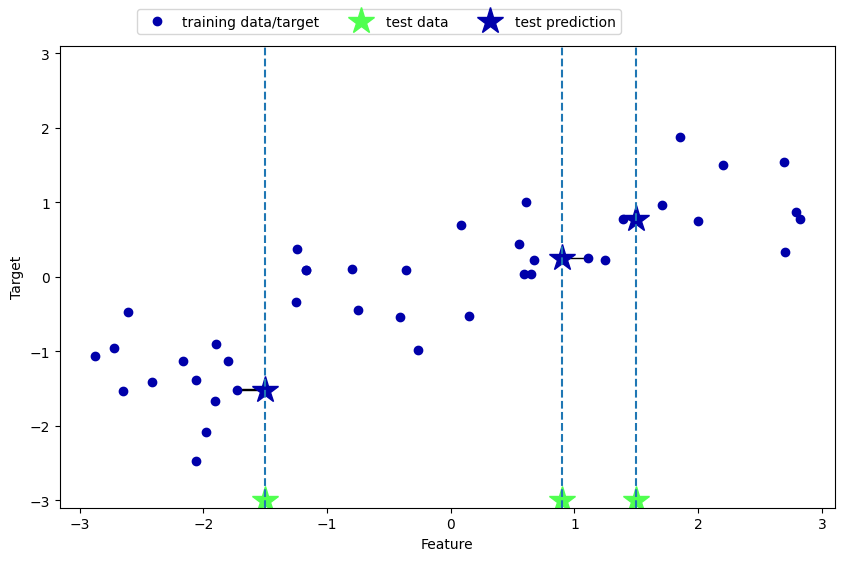

In [28]:
# plotting wave data for n=1
mglearn.plots.plot_knn_regression(n_neighbors=1)

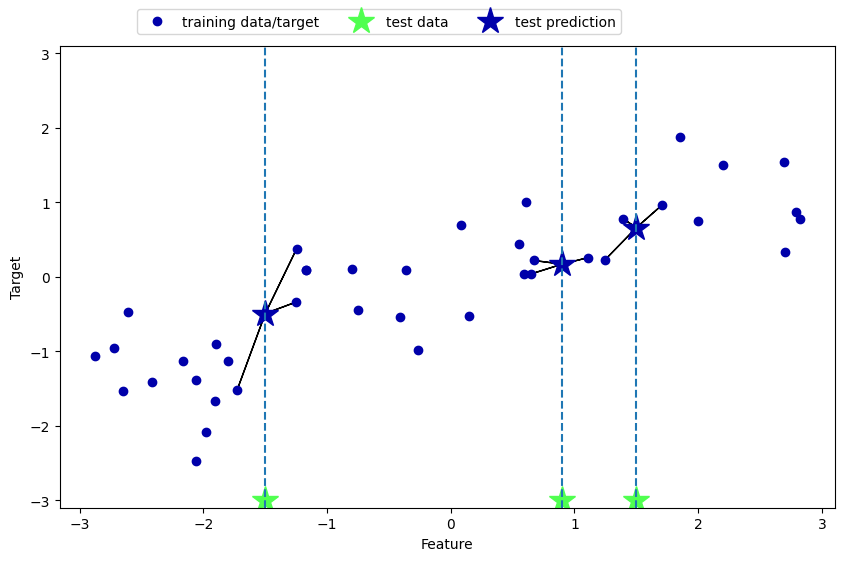

In [29]:
# plotiing data when n = 3
mglearn.plots.plot_knn_regression(n_neighbors=3)

In [30]:
# knn regression for wave dataset
from sklearn.neighbors import KNeighborsRegressor
X,y = mglearn.datasets.make_wave(n_samples=40)

In [31]:
# splitting the datasets
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

In [33]:
# instantiate model with neighbors = 3
knn_reg = KNeighborsRegressor(n_neighbors=3)
knn_reg.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=3)

In [34]:
# model evaluation
print(f'Test Set Prediction: {knn_reg.predict(X_test)}')

Test Set Prediction: [-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [35]:
# R^2 value -- R^2 = coefficient determination
print(f'Test Set Accuracy: {knn_reg.score(X_test,y_test):.2f}')


Test Set Accuracy: 0.83


**Analyzing KNN Regression**

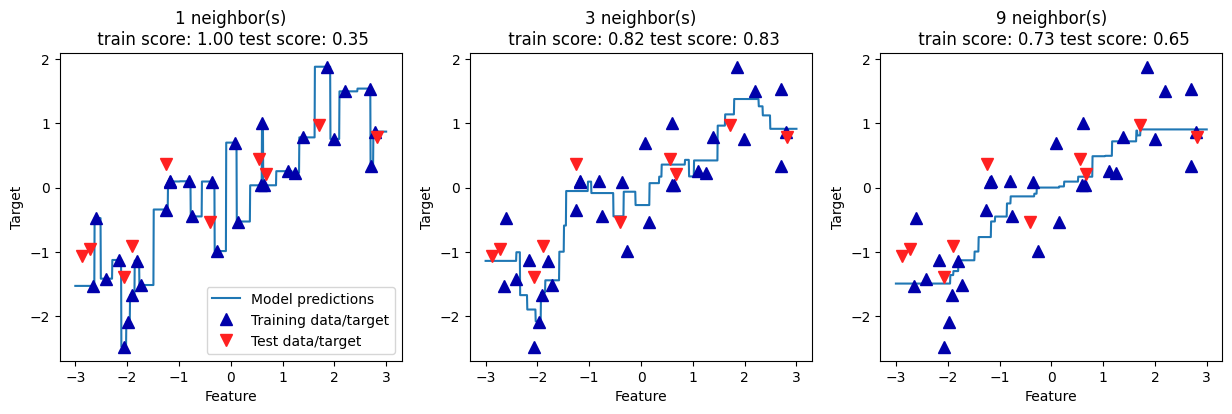

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# create 1,000 data points, evenly spaced between -3 and 3
line = np.linspace(-3, 3, 1000).reshape(-1, 1)
for n_neighbors, ax in zip([1, 3, 9], axes):
    # make predictions using 1, 3, or 9 neighbors
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)

    ax.set_title(
        "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
            n_neighbors, reg.score(X_train, y_train),
            reg.score(X_test, y_test)))
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target",
                "Test data/target"], loc="best")

* Using **only 1 neighbor (k=1)** in k-NN:

  * Each training point strongly affects the prediction.
  * The prediction **changes sharply** from point to point.
  * This causes **unstable or "jumpy" predictions**.

* Using **more neighbors (higher k)**:

  * Predictions become **smoother and more stable**.
  * But the model **doesn’t fit the training data as closely** (less flexible).


### ✅ **Strengths of k-NN:**

* **Easy to understand** and implement.
* Often gives **reasonable performance without much tuning**.
* **Fast to build** the model (no actual training phase).
* Good **baseline algorithm** to try before advanced models.

---

### ❌ **Weaknesses of k-NN:**

* **Slow prediction** for large datasets (many samples or features).
* Performs **poorly on high-dimensional data** (many features).
* **Bad with sparse data** (many zeros in features).
* **Sensitive to data preprocessing** (e.g., feature scaling is essential).
* Not commonly used in practice due to above limitations.

---

### ⚙️ **Key Parameters:**

* **`n_neighbors`** (k): Number of neighbors to consider.

  * Common values: **3 or 5**
  * Needs tuning for best results.
* **Distance metric**: Defines how “close” points are.

  * Default: **Euclidean distance**
  * Others: Manhattan, cosine, etc. (not covered in detail here)


